In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

import sys

sys.path.append('../src')

from Config.config import PATHS

import warnings
warnings.filterwarnings("ignore")

### Test focal region similarity

In [2]:
from Classes.focal_regions import FocalRegion

History:
 [[1 1]
 [1 0]
 [0 1]]
------------------------------------------------------------


<Axes: >

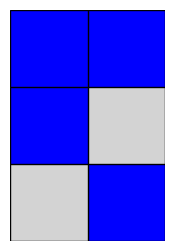

In [3]:
history = np.array([[1, 1], [1, 0], [0, 1]])
# history = np.array([[1], [1], [0]])
print('History:\n', history)
print('-'*60)
file_name = Path('..', 'LaTeX', 'history_1.png')
FocalRegion.draw_region(history, file=file_name)

<Axes: >

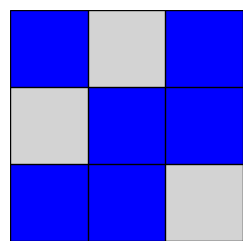

In [4]:
region = np.array([[1, 1, 0], [1, 0, 1], [0, 1, 1]])
region = FocalRegion.cycle_region(region, 1)
FocalRegion.draw_region(region)

<Axes: >

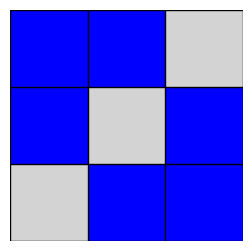

In [5]:
region = np.array([[1, 1, 0], [1, 0, 1], [0, 1, 1]])
fra = FocalRegion(region, "alternation")
fra.debug = True
file_name = Path('..', 'LaTeX', 'FRA_region_1.png')
FocalRegion.draw_region(region, file=file_name)


In [6]:
fra.get_action_preferences(history, 0)

	Cicle from column 0:
[[1 1]
 [1 0]
 [0 1]]
	Similarity score: 1.0
------------------------------------------------------------
	Cicle from column 1:
[[1 0]
 [0 1]
 [1 1]]
	Similarity score: 0.3333333333333333
------------------------------------------------------------
	Cicle from column 2:
[[0 1]
 [1 1]
 [1 0]]
	Similarity score: 0.3333333333333333
------------------------------------------------------------
------------------------------------------------------------
Scores: ['1.0', '0.33', '0.33']
Finding preferences for player 0 according to region
Pattern at column 0 assigns similarity 1.0 to action=no-go
Pattern at column 1 assigns similarity 0.3333333333333333 to action=go
Pattern at column 2 assigns similarity 0.3333333333333333 to action=go
Action preferences: ['1.0', '0.33']
------------------------------------------------------------


[np.float64(1.0), np.float64(0.3333333333333333)]

<Axes: >

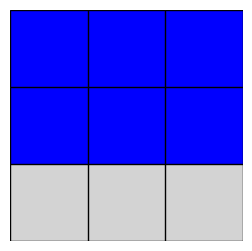

In [7]:
region = np.array([[1, 1, 1], [1, 1, 1], [0, 0, 0]])
fra = FocalRegion(region, "segmentation")
fra.debug = True
file_name = Path('..', 'LaTeX', 'FRA_region_2.png')
FocalRegion.draw_region(region, file=file_name)

In [8]:
fra.get_action_preferences(history, 0)

	Cicle from column 0:
[[1 1]
 [1 1]
 [0 0]]
	Similarity score: 0.6666666666666666
------------------------------------------------------------
	Cicle from column 1:
[[1 1]
 [1 1]
 [0 0]]
	Similarity score: 0.6666666666666666
------------------------------------------------------------
	Cicle from column 2:
[[1 1]
 [1 1]
 [0 0]]
	Similarity score: 0.6666666666666666
------------------------------------------------------------
------------------------------------------------------------
Scores: ['0.67', '0.67', '0.67']
Finding preferences for player 0 according to region
Pattern at column 0 assigns similarity 0.6666666666666666 to action=go
Pattern at column 1 assigns similarity 0.6666666666666666 to action=go
Pattern at column 2 assigns similarity 0.6666666666666666 to action=go
Action preferences: ['0', '0.67']
------------------------------------------------------------


[0, np.float64(0.6666666666666666)]

### Test Focal Regions

In [9]:
from Classes.focal_regions import SetFocalRegions

In [10]:
sfr = SetFocalRegions(
    num_agents=3,
    threshold=2/3,
    len_history=2,
    c=0.9,
    steepness=20,
    max_regions=3,
)
sfr.debug = True

Generating focal regions for 3 agents and 0.6666666666666666 threshold
Equalizing region sizes
Action preferences according to region 1:
['0.33', '0.67']
Action preferences according to region 2:
['0.33', '0']
Action preferences according to region 3:
['0', '1.0']


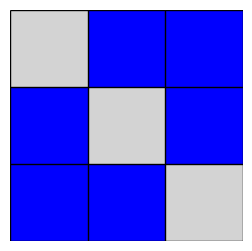

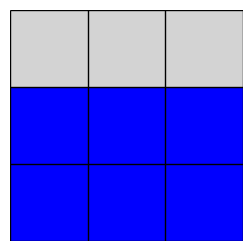

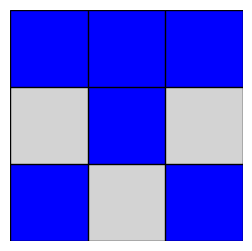

In [11]:
sfr.generate_focal_regions()
for i, region in enumerate(sfr.focal_regions):
    FocalRegion.draw_region(region.focal_region)
    action_preferences = region.get_action_preferences(history, 0)
    print(f"Action preferences according to region {i+1}:\n{[f"{round(score, 2)}" for score in action_preferences]}")

In [12]:
for i, region in enumerate(sfr.focal_regions):
    action_preferences = region.get_action_preferences(history, 0)
    print(f"Action preferences according to region {i+1}:\n{[f"{round(score, 2)}" for score in action_preferences]}")

Action preferences according to region 1:
['0.33', '0.67']
Action preferences according to region 2:
['0.33', '0']
Action preferences according to region 3:
['0', '1.0']


In [13]:
sfr.history = history
sfr.get_action_preferences(0)

Considering preferences from the viewpoint of agent 0
------------------------------------------------------------
Similarities according to region 0:
	Raw similarities: ['0.33', '0.67']
	Sigmoid similarities: ['0.0', '0.01']
Similarities according to region 1:
	Raw similarities: ['0.33', '0']
	Sigmoid similarities: ['0.0', '0.0']
Similarities according to region 2:
	Raw similarities: ['0', '1.0']
	Sigmoid similarities: ['0.0', '1.0']
Aggregated preferences: (no go=2.7138869707154747e-05; go=1.0105767202334024)
Normalized preferences: (no go=0.2668723105780969; go=0.7331276894219031)


array([0.26687231, 0.73312769])

In [14]:
sfr.normalized_logistic(np.array([0.83, 0.17]))

array([2.24587598e-01, 5.00821889e-07])

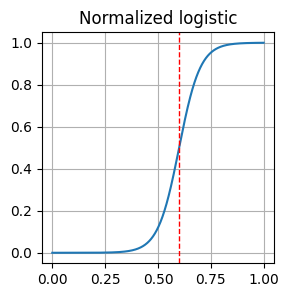

In [16]:
X = np.linspace(0, 1, 1000)
sfr.c = 0.6
Y = sfr.normalized_logistic(X)

fig, ax = plt.subplots(1, 1, figsize=(3,3))
sns.lineplot(x=X, y=Y, ax=ax)
ax.axvline(x=sfr.c, color='red', linestyle='--', linewidth=1)
ax.set_title(f'Normalized logistic')
ax.grid()

fig.savefig(PATHS['LaTeX'] / 'logistic.png', dpi=300)

---